In [2]:
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/Heart_disease_cleveland_new.csv')

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


In [8]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("/content/drive/MyDrive/Heart_disease_cleveland_new.csv")
df = df.replace('?', np.nan)
df = df.apply(pd.to_numeric)
df = df.fillna(df.mean())

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = ((df < lower) | (df > upper))


print("Outlier rows:")
print(df[outliers.any(axis=1)])

df = df[~outliers.any(axis=1)]

print("After removing outliers:", df.shape)

X = df.drop("target", axis=1)
y = df["target"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)






Outlier rows:
     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   0       145   233    1        2      150      0      2.3   
1     67    1   3       160   286    0        2      108      1      1.5   
9     53    1   3       140   203    1        2      155      1      3.1   
12    56    1   2       130   256    1        2      142      1      0.6   
14    52    1   2       172   199    1        0      162      0      0.5   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
285   58    1   3       114   318    0        1      140      0      4.4   
286   58    0   3       170   225    1        2      146      1      2.8   
296   59    1   3       164   176    1        2       90      0      1.0   
298   45    1   0       110   264    0        0      132      0      1.2   
299   68    1   3       144   193    1        0      141      0      3.4   

     slope  ca  thal  target  
0        2   0     2       0  
1        1 

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import *

model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Decision Tree")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))





Decision Tree
Confusion Matrix:
[[22  2]
 [ 7 13]]
Accuracy: 0.7954545454545454


Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.84      0.82       125
           1       0.77      0.73      0.75        91

    accuracy                           0.79       216
   macro avg       0.79      0.78      0.78       216
weighted avg       0.79      0.79      0.79       216

Confusion Matrix:
[[105  20]
 [ 25  66]]


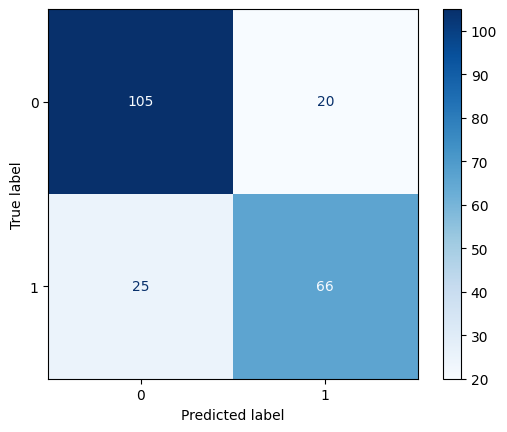

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = DecisionTreeClassifier()

y_pred = cross_val_predict(model, X, y, cv=skf)

print("Classification Report:")
print(classification_report(y, y_pred))

cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:")
print(cm)

# 6. Optional: Visualise the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()




--- NAIVE BAYES REPORT ---
              precision    recall  f1-score   support

           0       0.90      0.75      0.82        24
           1       0.75      0.90      0.82        20

    accuracy                           0.82        44
   macro avg       0.82      0.82      0.82        44
weighted avg       0.83      0.82      0.82        44

--- SVM REPORT ---
              precision    recall  f1-score   support

           0       0.88      0.92      0.90        24
           1       0.89      0.85      0.87        20

    accuracy                           0.89        44
   macro avg       0.89      0.88      0.88        44
weighted avg       0.89      0.89      0.89        44



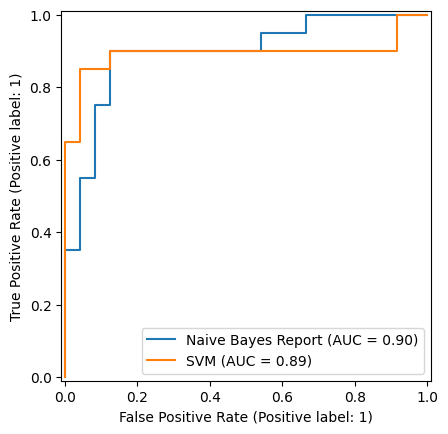

In [16]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, RocCurveDisplay

nb = GaussianNB()

svm = SVC(probability=True, random_state=42)

nb.fit(X_train, y_train)
print("--- NAIVE BAYES REPORT ---")
print(classification_report(y_test, nb.predict(X_test)))

svm.fit(X_train, y_train)
print("--- SVM REPORT ---")
print(classification_report(y_test, svm.predict(X_test)))

fig, ax = plt.subplots()
RocCurveDisplay.from_estimator(nb, X_test, y_test, ax=ax, name="Naive Bayes Report")

RocCurveDisplay.from_estimator(svm, X_test, y_test, ax=ax, name="SVM")
plt.show()




In [21]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
X, y = make_regression(n_samples=100, n_features=5, noise=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("--- LINEAR REGRESSION RESULTS ---")
print("MAE: ", mean_absolute_error(y_test, lr_pred))
print("MSE: ", mean_squared_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))




--- LINEAR REGRESSION RESULTS ---
MAE:  6.033576237251003
MSE:  61.75744382500503
RMSE: 7.858590447720573
